# AI 221 Assignment 5: Cross Validation and Hyperparameter Search

<b>Description:</b> This notebook demonstrates prediction of car acceptability, employing cross validation and hyperparameter search. Dataset used is the Car Evaluation Dataset that can be found on https://archive.ics.uci.edu/dataset/19/car+evaluation.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

## Data fetching and preliminary data checks

In [1]:
# UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# fetching the car evaluation dataset 
car_evaluation = fetch_ucirepo(id=19) # alternatively: fetch_ucirepo(name='Car Evaluation')
car_evaluation_df = car_evaluation.data.original

# checking the data
display(car_evaluation_df)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [2]:
# checking metadata
print("Metadata:")
print(car_evaluation.metadata) 
print()

# checking variable information
print("Variable information:")
print(car_evaluation.variables) 

Metadata:
{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Appl

In [3]:
# checking info of the DataFrame
car_evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


It can be seen that all of the seven (7) columns are of string (object) data type. 

In [4]:
# checking descriptive statistics for each column
car_evaluation_df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [5]:
# checking missing values
print(f"Missing values in the DataFrame: \n{car_evaluation_df.isnull().sum()}\n")

Missing values in the DataFrame: 
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64



It is evident that there are no missing values (as also explicitly mentioned in the dataset website).

In [6]:
# checking how many unique values per column
car_evaluation_df.nunique()

buying      4
maint       4
doors       4
persons     3
lug_boot    3
safety      3
class       4
dtype: int64

There are four (4) unique values in the `buying`, `maint`, `doors`, and `class` columns, while there are three (3) unique values for `persons`, `lug_boot`, and `safety` columns.

In [7]:
# checking the unique values of each column, and checking the count of each unique value of the column
# looping through all columns 
for col in list(car_evaluation_df.columns):
    print(f"'{col}' unique values: {car_evaluation_df[col].unique()}")
    print(f"Count for each '{col}' unique values: {car_evaluation_df[col].value_counts()}")
    print()

'buying' unique values: ['vhigh' 'high' 'med' 'low']
Count for each 'buying' unique values: buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

'maint' unique values: ['vhigh' 'high' 'med' 'low']
Count for each 'maint' unique values: maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

'doors' unique values: ['2' '3' '4' '5more']
Count for each 'doors' unique values: doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

'persons' unique values: ['2' '4' 'more']
Count for each 'persons' unique values: persons
2       576
4       576
more    576
Name: count, dtype: int64

'lug_boot' unique values: ['small' 'med' 'big']
Count for each 'lug_boot' unique values: lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

'safety' unique values: ['low' 'med' 'high']
Count for each 'safety' unique values: safety
low     576
med     576
high    576
Name: count, dtype: int64

'class' 

Based from the count, unique values of columns have the same number, except for `class` column which shows an abnormaly high number of `unacc` cars than `acc`, `good`, or `vgood`.

## EDA

In [8]:
# for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# for dataset manipulation and computation
import pandas as pd
import numpy as np

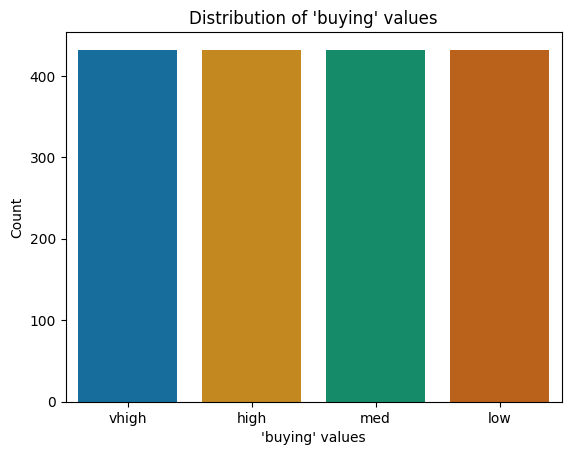

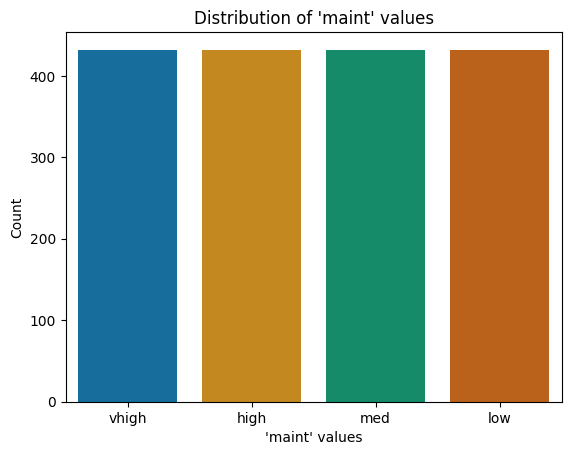

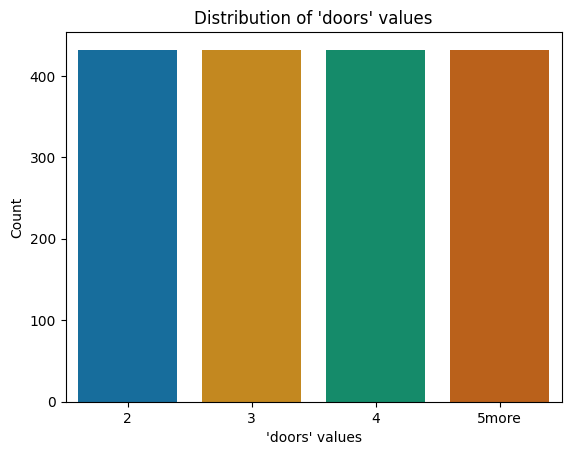

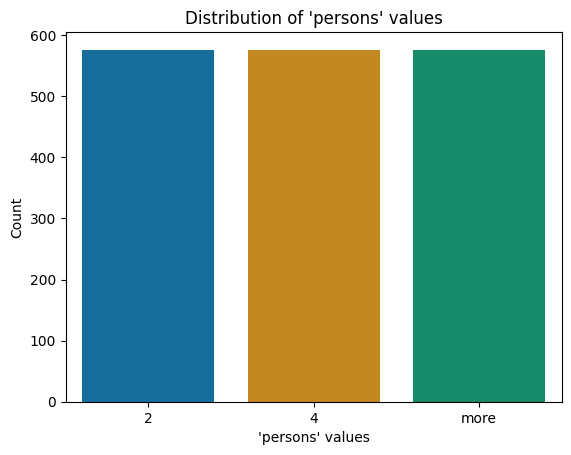

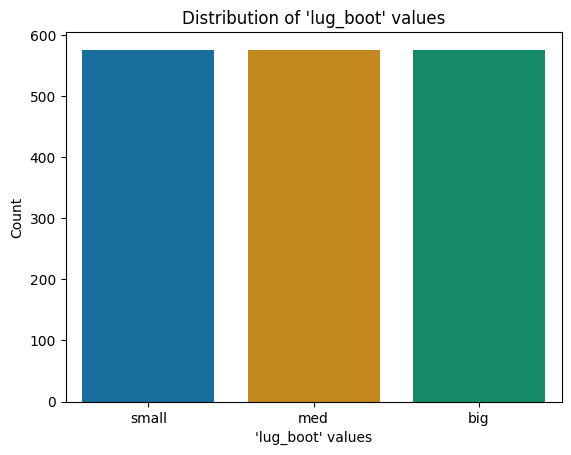

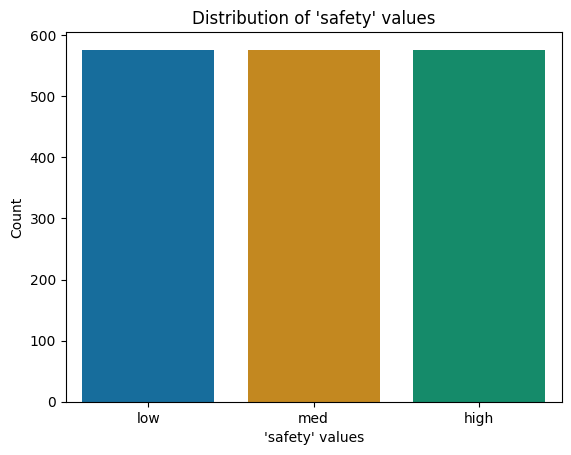

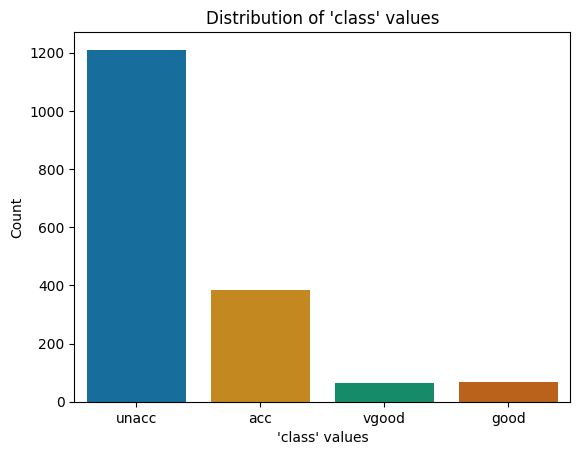

In [9]:
for col in list(car_evaluation_df.columns):
    # checking the distribution of each column
    sns.countplot(data=car_evaluation_df, x=col, hue=col, palette="colorblind")
    plt.xlabel(f"'{col}' values")
    plt.ylabel("Count")
    plt.title(f"Distribution of '{col}' values")
    plt.show()

As can be seen, all columns have uniform distribution (which confirms the count produced earlier), except for the `class` which shows that there is really a high number of `unacc` cars than `acc`, `vgood`, or `good`. This can potentially skew the prediction.

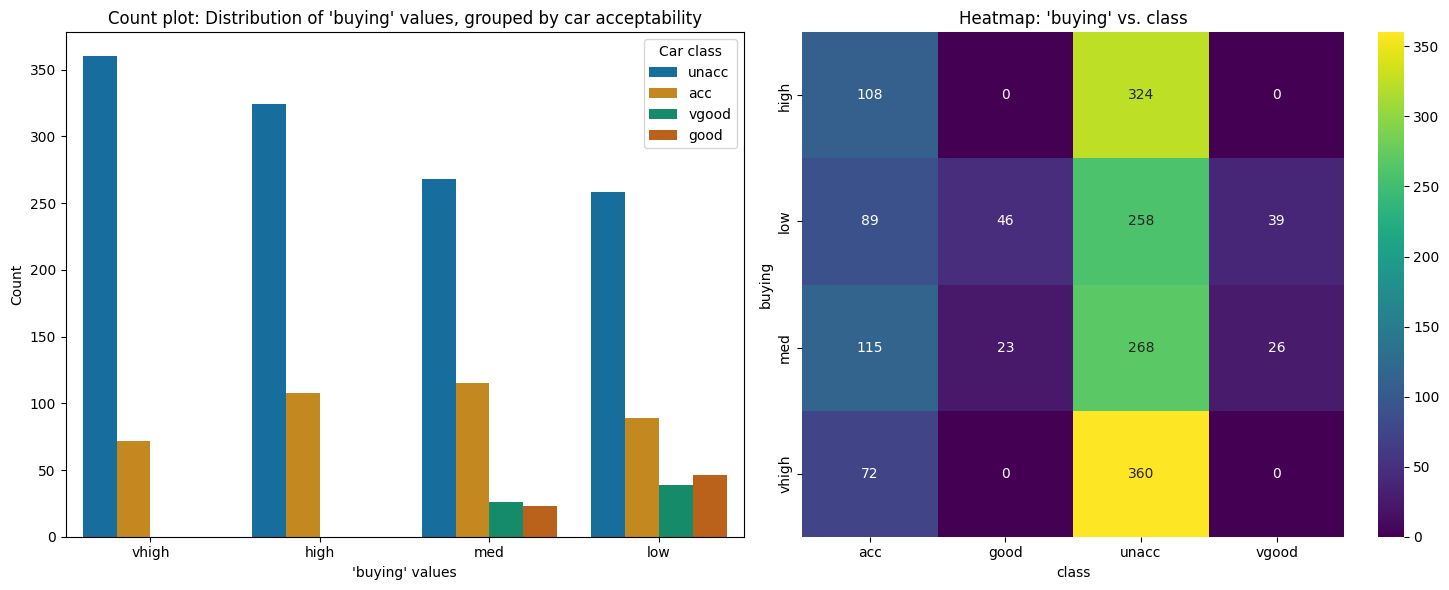

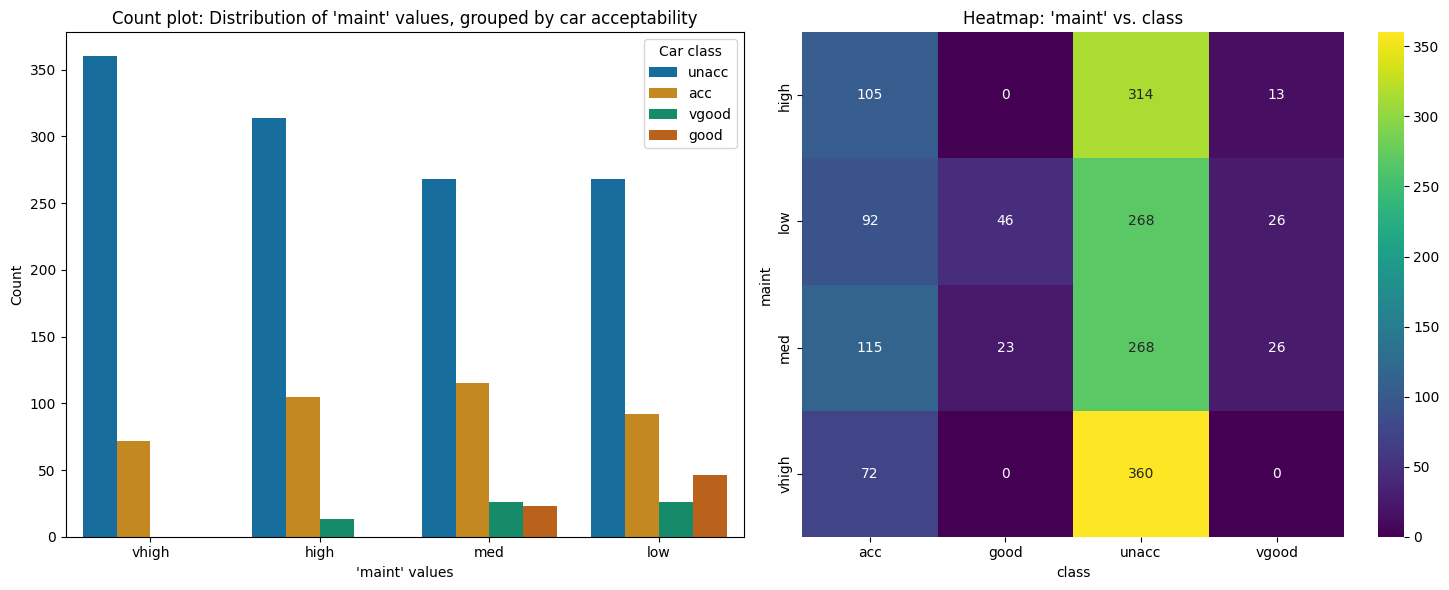

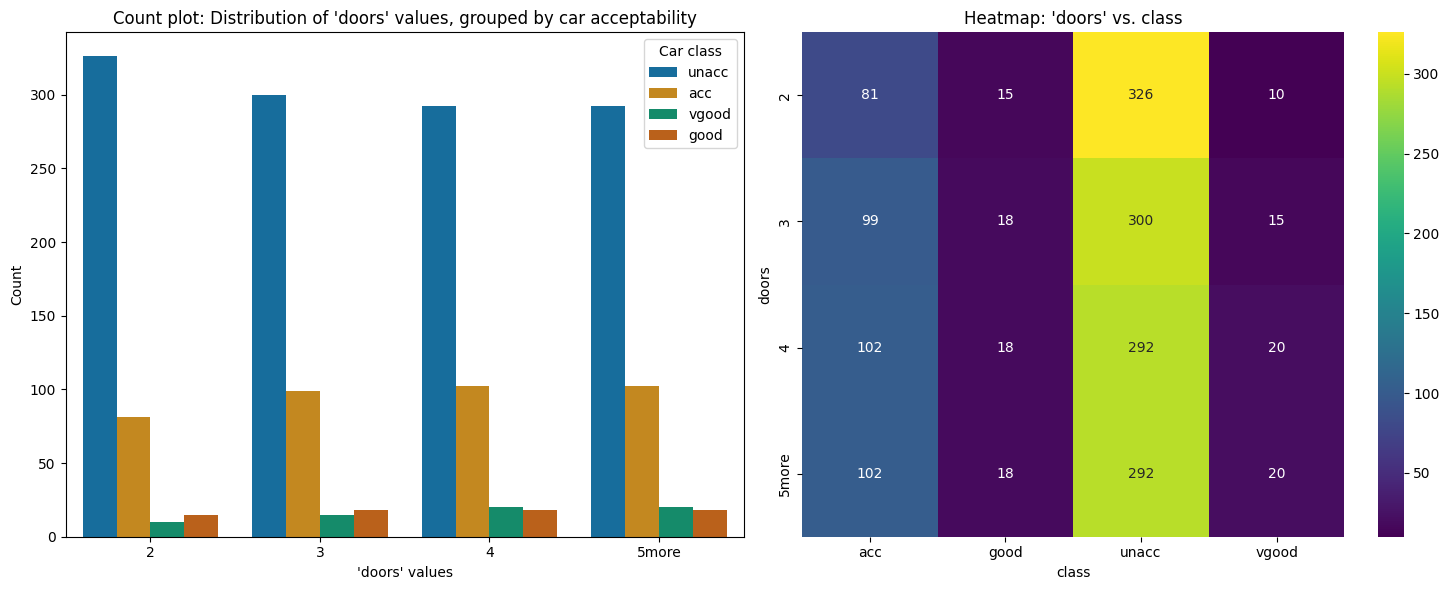

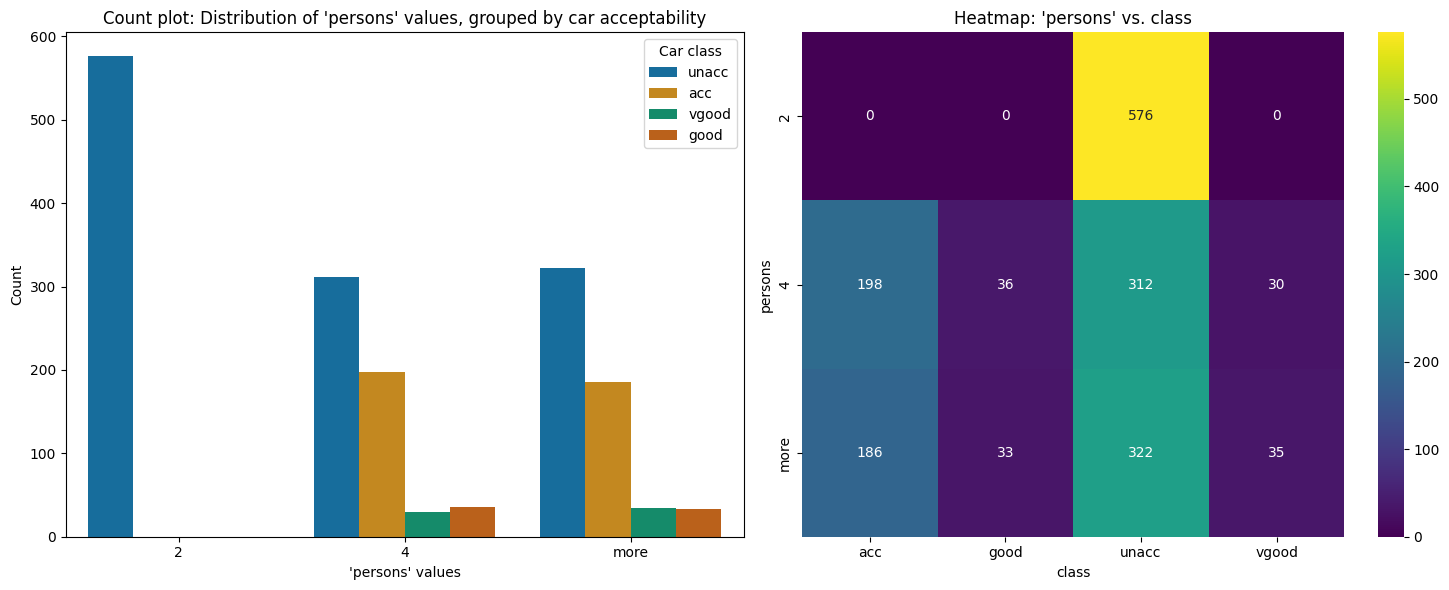

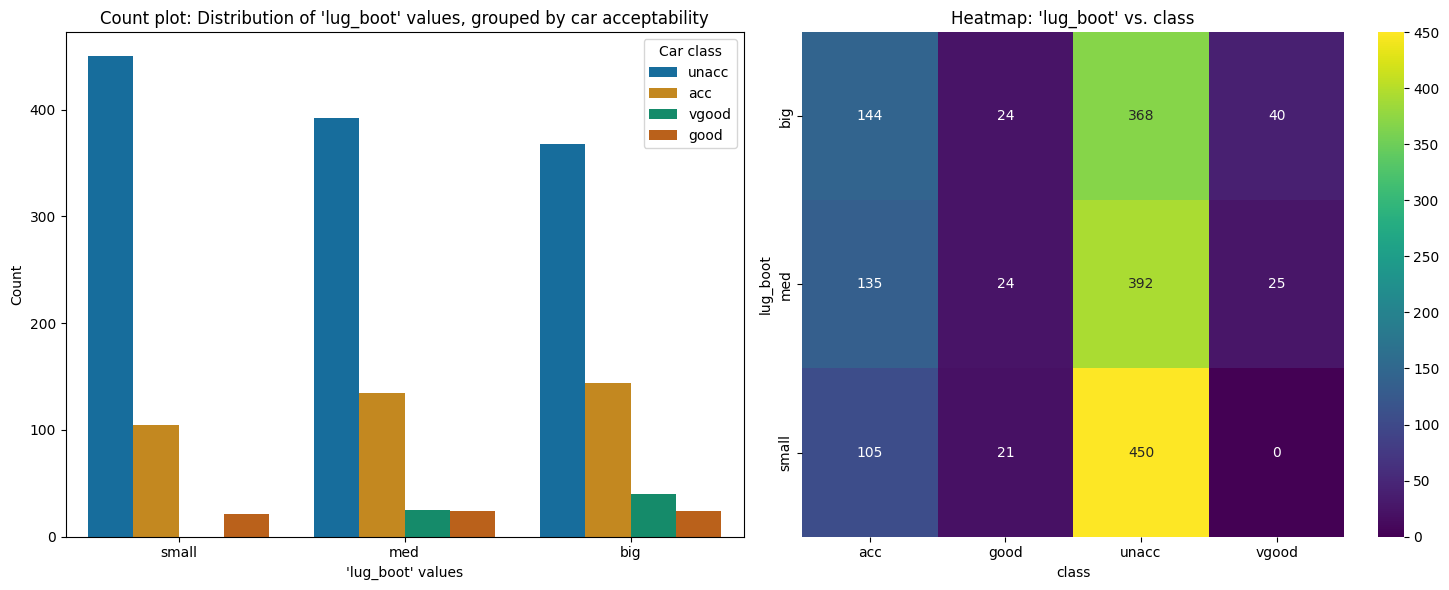

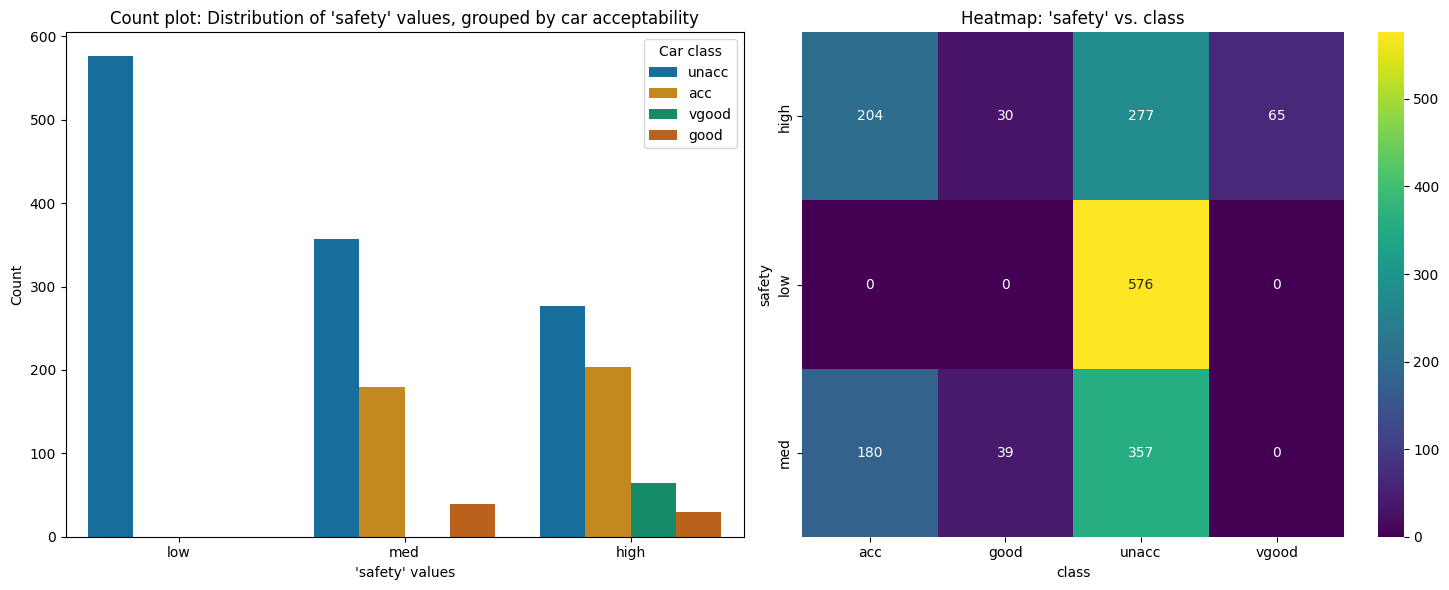

In [10]:
# looping through all columns except the class column (last one)
for col in list(car_evaluation_df.columns[:-1]):
    # creating subplot of 1 row, 2 columns (for grouped count plot and heatmap)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

    # count plot distribution of the column values, grouped by car acceptability
    sns.countplot(data=car_evaluation_df, x=col, hue="class", palette="colorblind", ax=axes[0])
    axes[0].set_xlabel(f"'{col}' values")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Count plot: Distribution of '{col}' values, grouped by car acceptability")
    axes[0].legend(title="Car class")

    # heatmap
    crosstab = pd.crosstab(car_evaluation_df[col], car_evaluation_df["class"])
    sns.heatmap(crosstab, annot=True, fmt='d', cmap="viridis", ax=axes[1])
    axes[1].set_title(f"Heatmap: '{col}' vs. class")
    
    plt.tight_layout()
    plt.show()

As can be seen, the `unacc` car class dominates across features.

## Data Processing

In [11]:
from sklearn.preprocessing import OrdinalEncoder # for encoding categorical values into ordinal values

# order mappings
buying_order = ['low', 'med', 'high', 'vhigh']
maint_order = ['low', 'med', 'high', 'vhigh']
doors_order = ['2', '3', '4', '5more']
persons_order = ['2', '4', 'more']
lug_boot_order = ['small', 'med', 'big']
safety_order = ['low', 'med', 'high']
class_order = ['unacc', 'acc', 'good', 'vgood'] # target variable

# list of the orders
orders = [buying_order, maint_order, doors_order, persons_order, lug_boot_order, safety_order, class_order]

# transforming the string values into orders
encoder = OrdinalEncoder(categories=orders)
encoded_car_evaluation_df = pd.DataFrame(encoder.fit_transform(car_evaluation_df), columns=car_evaluation_df.columns)

display(encoded_car_evaluation_df)


,buying,maint,doors,persons,lug_boot,safety,class
0,3.0,3.0,0.0,0.0,0.0,0.0,0.0
1,3.0,3.0,0.0,0.0,0.0,1.0,0.0
2,3.0,3.0,0.0,0.0,0.0,2.0,0.0
3,3.0,3.0,0.0,0.0,1.0,0.0,0.0
4,3.0,3.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...
1723,0.0,0.0,3.0,2.0,1.0,1.0,2.0
1724,0.0,0.0,3.0,2.0,1.0,2.0,3.0
1725,0.0,0.0,3.0,2.0,2.0,0.0,0.0
1726,0.0,0.0,3.0,2.0,2.0,1.0,2.0


In [12]:
# checking the data type of the columns
encoded_car_evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   buying    1728 non-null   float64
 1   maint     1728 non-null   float64
 2   doors     1728 non-null   float64
 3   persons   1728 non-null   float64
 4   lug_boot  1728 non-null   float64
 5   safety    1728 non-null   float64
 6   class     1728 non-null   float64
dtypes: float64(7)
memory usage: 94.6 KB


In [13]:
# isolating the features and target
X = encoded_car_evaluation_df.drop("class", axis=1).to_numpy()
y = encoded_car_evaluation_df["class"].to_numpy().reshape((-1, 1))

print("Features array:")
print(X)
print()
print("Target array:")
print(y)

Features array:
[[3. 3. 0. 0. 0. 0.]
 [3. 3. 0. 0. 0. 1.]
 [3. 3. 0. 0. 0. 2.]
 ...
 [0. 0. 3. 2. 2. 0.]
 [0. 0. 3. 2. 2. 1.]
 [0. 0. 3. 2. 2. 2.]]

Target array:
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [2.]
 [3.]]


In [14]:
from sklearn.model_selection import train_test_split # for data splitting

# splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=6)

# checking shapes of X
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print()

# checking shapes of y
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")
print()

X_train.shape: (1209, 6)
X_test.shape: (519, 6)

y_train.shape: (1209, 1)
y_test.shape: (519, 1)



In [15]:
# implementing SMOTE to balance the training data
from imblearn.over_sampling import SMOTE

# applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# checking shapes of balanced X_train and y_train
print(f"X_train_smote.shape: {X_train_smote.shape}")
print(f"y_train_smote.shape: {y_train_smote.shape}")

X_train_smote.shape: (3380, 6)
y_train_smote.shape: (3380,)


## SVC Implementation (with Cross-Validation and Hyperparameter Search)

In [16]:
# scikit-learn
from sklearn.svm import SVC # for implementation of SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV # for cross-validation and hyperparameter search
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay # for evaluation of SVM
from sklearn.inspection import permutation_importance # for inspection

# for timing of grid search and randomized search
import time

### Grid Search

GridSearchCV took 4.84 seconds.

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       365
         1.0       0.96      1.00      0.98       115
         2.0       1.00      0.77      0.87        22
         3.0       0.94      1.00      0.97        17

    accuracy                           0.99       519
   macro avg       0.98      0.94      0.96       519
weighted avg       0.99      0.99      0.99       519



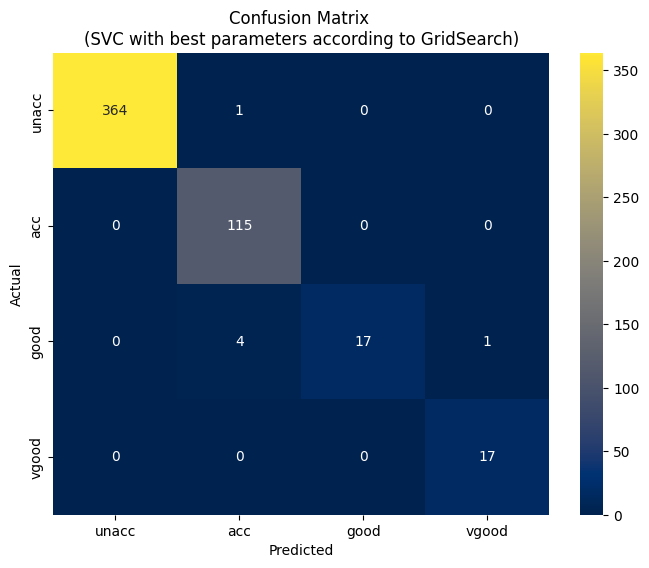

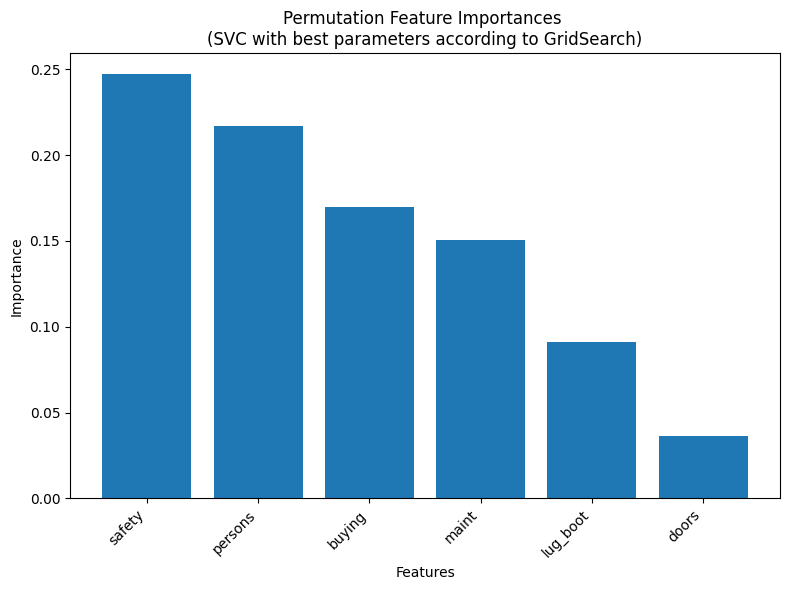

In [17]:
# specifying hyperparameter values to search from
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 1, 10],
    'kernel': ['rbf', 'linear', 'sigmoid']
}

# performing stratified k-fold cross-validation and grid search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
grid_search = GridSearchCV(SVC(random_state=6), param_grid, cv=skf, scoring='f1_weighted', n_jobs=-1)

start_time = time.time()  # recording start time
grid_search.fit(X_train_smote, y_train_smote)
end_time = time.time()  # recording end time

elapsed_time_grid_search = end_time - start_time
print(f"GridSearchCV took {elapsed_time_grid_search:.2f} seconds.\n")

# printing best parameters and predicting using the best estimator
print(f"Best Parameters: {grid_search.best_params_}\n")
best_svc = grid_search.best_estimator_
y_pred_best = best_svc.predict(X_test)

# evaluating the best classifier
print("Classification report:")
print(classification_report(y_test, y_pred_best))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="cividis", xticklabels=class_order, yticklabels=class_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix \n(SVC with best parameters according to GridSearch)")
plt.show()

# plotting feature importance since decision boundaries cannot be visualized if all features are used for SVC
result = permutation_importance(best_svc, X_test, y_test, n_repeats=10, random_state=6)
feature_names = encoded_car_evaluation_df.columns[0:-1]

# ordering feature importances from highest to lowest
sorted_idx = result.importances_mean.argsort()[::-1]  # get indices that would sort the array in descending order

sorted_feature_names = feature_names[sorted_idx]
sorted_importances = result.importances_mean[sorted_idx]

plt.figure(figsize=(8, 6))
plt.bar(sorted_feature_names, sorted_importances)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title(f"Permutation Feature Importances \n(SVC with best parameters according to GridSearch)")
plt.tight_layout()
plt.show()

### Randomized Search

RandomizedSearchCV took 8.56 seconds.

Best Parameters: {'C': np.float64(93.45584831900192), 'gamma': np.float64(1.869009672988477), 'kernel': 'rbf'}

Classification report:
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95       365
         1.0       0.94      0.83      0.88       115
         2.0       1.00      0.27      0.43        22
         3.0       1.00      0.53      0.69        17

    accuracy                           0.92       519
   macro avg       0.96      0.66      0.74       519
weighted avg       0.92      0.92      0.91       519



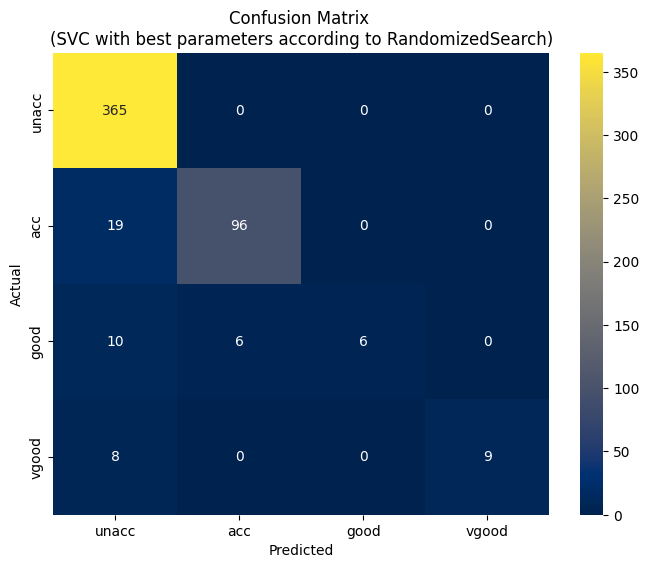

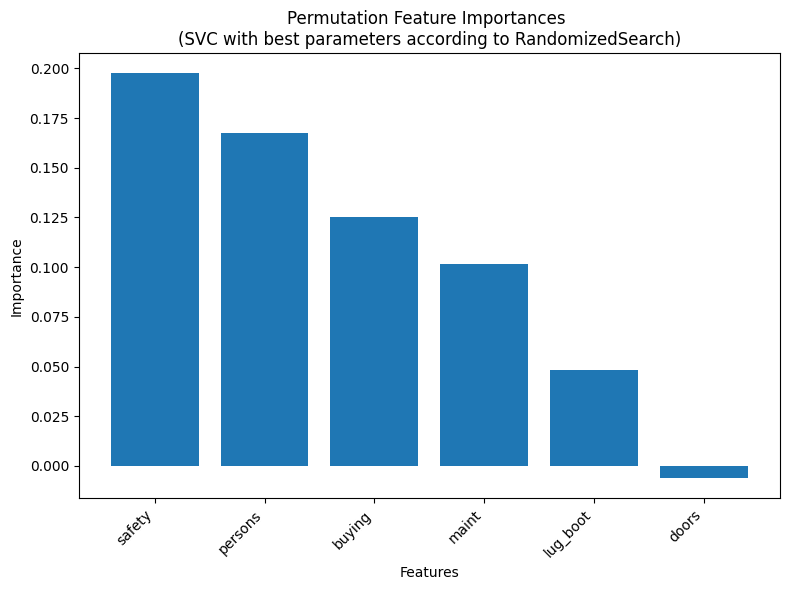

In [18]:
from scipy.stats import loguniform

# specifying hyperparameter values to search from
param_distributions = {
    'C': loguniform(0.001, 1000),  # Log-uniform distribution between 0.001 and 1000
    'gamma': loguniform(0.001, 1000),  # Log-uniform distribution between 0.001 and 1000
    'kernel': ['rbf', 'linear', 'sigmoid'],
}

# performing stratified k-fold cross-validation and randomized search
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
random_search = RandomizedSearchCV(SVC(random_state=6), param_distributions, n_iter=100, cv=skf, scoring='f1_weighted', n_jobs=-1, random_state=6)

start_time = time.time()  # recording start time
random_search.fit(X_train_smote, y_train_smote)
end_time = time.time()  # recording end time

elapsed_time_random_search = end_time - start_time
print(f"RandomizedSearchCV took {elapsed_time_random_search:.2f} seconds.\n")

# printing best parameters and predicting using the best estimator
print(f"Best Parameters: {random_search.best_params_}\n")
best_svc = random_search.best_estimator_
y_pred_best = best_svc.predict(X_test)

# evaluating the best classifier
print("Classification report:")
print(classification_report(y_test, y_pred_best))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="cividis", xticklabels=class_order, yticklabels=class_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix \n(SVC with best parameters according to RandomizedSearch)")
plt.show()

# plotting feature importance since decision boundaries cannot be visualized if all features are used for SVC
result = permutation_importance(best_svc, X_test, y_test, n_repeats=10, random_state=6)
feature_names = encoded_car_evaluation_df.columns[0:-1]

# ordering feature importances from highest to lowest
sorted_idx = result.importances_mean.argsort()[::-1]  # get indices that would sort the array in descending order

sorted_feature_names = feature_names[sorted_idx]
sorted_importances = result.importances_mean[sorted_idx]

plt.figure(figsize=(8, 6))
plt.bar(sorted_feature_names, sorted_importances)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title(f"Permutation Feature Importances \n(SVC with best parameters according to RandomizedSearch)")
plt.tight_layout()
plt.show()

## Summary

* Car acceptability classification has been done using the Car Evaluation Dataset.
* A major finding from the EDA conducted is that the dataset is highly imbalanced in terms of car acceptability class; that is, the `unacc` class dominates across all features.
* To solve the data imbalance issue, SMOTE is used in the training data.
* With regards to the specific classification method used, SVC is implemented with the best parameters obtained using grid search and randomized search. After searching for the best parameters, the model is evaluated: classification reports and confusion matrices are produced. Moreover, since it is impossible to plot the decision boundaries, feature importances are instead obtained and plotted. From this, it shows that `safety` is the best predictor of car acceptability.
* Grid Search took 4.84 seconds to obtain the best parameters from a specified (highly-restricted) grid. The best parameters obtained for the SVC are 'C' of 100, 'gamma' of 'scale', and 'kernel' of 'rbf'. The SVC with these parameters produced a test accuracy of 99%, based on the classification report.
* Randomized Search took 8.56 seconds to obtain the best parameters from a specified (more open) distribution. The best parameters obtained for the SVC are 'C' of 93.45584831900192, 'gamma' of 1.869009672988477, and 'kernel' of 'rbf'. The SVC with these parameters produced a test accuracy of 92%, based on the classification report.
* The experiments compared and contrasted grid search and randomized search in terms of finding the best hyperparameters. In terms of search time, it was surprising that randomized search took longer than grid search, but this is due to the former searching in a larger space compared to the latter (since initial experiments showed that it really took a long time, more than 30 minutes, to search from the grid with many parameter options; thus, the space specified for grid search is highly-restricted). In terms of accuracy, the SVC with the best parameters obtained from grid search has a higher score. Perhaps this is due to chance in that it happened that within the highly-restricted search grid, the best parameters are already preset.
* Grid Search is not absolutely superior to Randomized Search, and vice-versa. Using one over the other depends on the situation and priority: is a faster search required or should the "best" set of parameters be obtained from a larger space?
* Based from the experiments, the best SVC model obtained is one with parameters 'C' of 100, 'gamma' of 'scale', and 'kernel' of 'rbf' since, with these parameters, a 99% test accuracy is obtained.